https://pierreproulx.espaceweb.usherbrooke.ca/notebooks/python_3.html

In [16]:
from math import *
for i in range(0,10):
    if i%3 == 0:        
        print(i)
    else:
        print(10)
print( 'voici')

0
10
10
3
10
10
6
10
10
9
voici


In [17]:
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
x,y=sp.symbols('x,y');eq1= 2*x+  y+1
eq2=-4*x-5*y+4;solution=sp.solve((eq1,eq2),x,y)
solution

In [5]:
[z1,z2]=sp.solve(x**2-3*x+4)
display(z1)
solution=sp.solve(x**2-3*x+4)
display(solution)
display(type(solution))

list

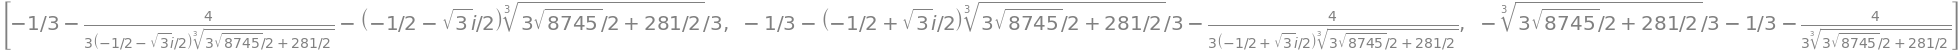

In [6]:
from IPython.display import *
sp.init_printing(use_latex=True)
racines=sp.solve(x**3+x**2-x+10);display(racines)

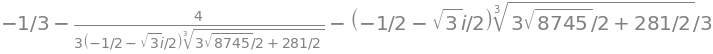

In [7]:
display(racines[0])

In [8]:
racines[0].evalf()

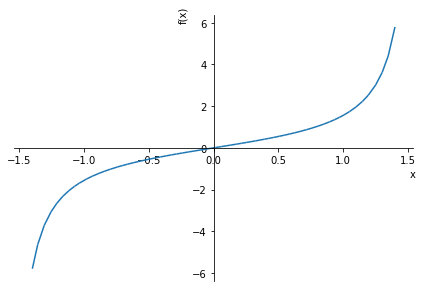

In [9]:
from sympy import plot,tan
x=sp.symbols('x')
plot(tan(x),(x,-1.4,1.4))

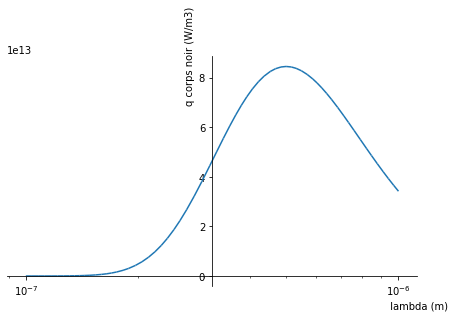

In [10]:
import sympy as sp
from IPython.display import *
%matplotlib inline
sp.init_printing(use_latex=True)
%matplotlib inline

def planck(T,lam):
    h=6.62608e-34
    k=1.38066e-23
    c=2.99792e8
    P1=2*sp.pi*c**2*h
    P2=lam**5
    P3=sp.exp(c*h/lam/k/T)-1
    return P1/P2/P3
lam=sp.symbols('lam')
sp.plot(planck(5800,lam),(lam,100e-9,1000e-9),ylabel='q corps noir (W/m3)',
        xlabel=' lambda (m)',xscale='log')

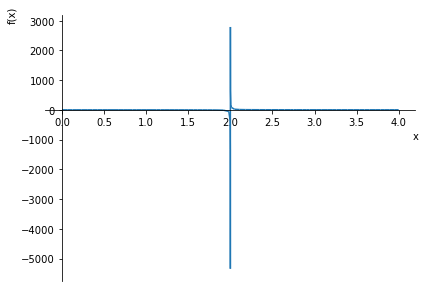

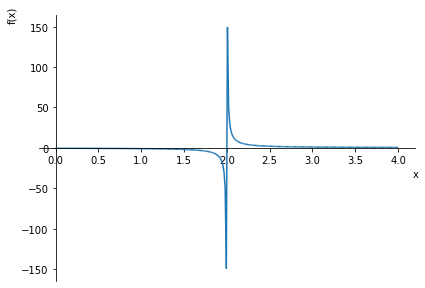

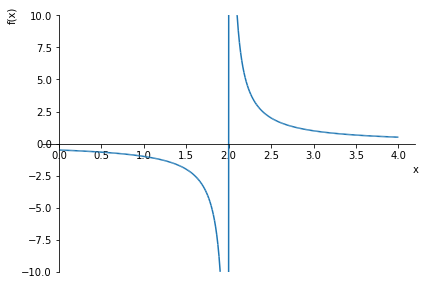

In [11]:
x = sp.symbols('x')
 
# Range non fixé dans la direction y. options par default
sp.plot(1/(x - 2), (x, 0, 4))

# Range non fixé dans la direction y, mais l'algorithme de calcul
# n'adapte pas les intervalles pour mieux couvrir la fonction. 
# adaptive = False donne des intervalles fixes.

sp.plot(1/(x - 2), (x, 0, 4),adaptive=False)
 
# On peut améliorer en changeant les limites de l'affichage en y.
sp.plot(1/(x - 2), (x, 0, 4), ylim=(-10, 10), adaptive=False)

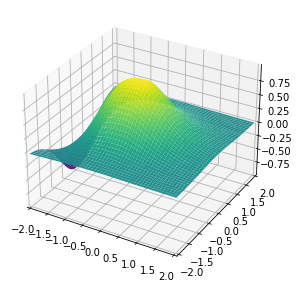

In [12]:
import sympy as sp
from sympy.plotting import plot3d
#
#
%matplotlib inline
# la commande ci-dessus doit être utilisée si les graphes n'apparaissent
# pas dans le document notebook mais dans des fenetres externes.
#
#
x,y=sp.symbols('x y')
plot3d((sp.exp(-(x**1.5+y**2))),(x,-2,2),(y,-2,2))

Tracons la distribution à 400 degrés, pour de l'argon à pression atmosphérique. n est la concentration atomique en atomes par m^3, etc..

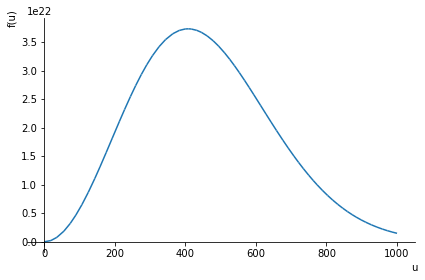

In [13]:
import sympy as sp
from IPython.display import *
%matplotlib inline
sp.init_printing(use_latex=True)
m,k,T,u = sp.symbols('m,k,T,u',positive=True)
n,f = sp.symbols('n,f')
temp=(m/(2*sp.pi*k*T))**(3/2)
f=4*sp.pi*n*u**2*temp*sp.exp(-(m*u**2/(2*k*T)))
f=f.subs([(m,40/6.023e26),(T,400),(k,1.38e-23),(n,101325/400/1.38e-23)])
sp.plot(f,(u,0,1000))

Maintenant intégrons la distribution pour obtenir la vitesse moyenne et l'énergie cinétique moyenne:

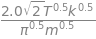

In [14]:
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
m,k,T,u = sp.symbols('m,k,T,u',positive=True)
n,f = sp.symbols('n,f')
temp=(m/(2*sp.pi*k*T))**(3/2)
f=4*sp.pi*n*u**2*temp*sp.exp(-(m*u**2/(2*k*T)))
U=sp.integrate(u*f,(u,0,sp.oo))/sp.integrate(f,(u,0,sp.oo))
display(U)
K=1/2*m*sp.integrate(u**2*f,(u,0,sp.oo))/sp.integrate(f,(u,0,sp.oo))
display(K)

On peut aussi voir comment on calcule obtient équation d'Hagen-Poiseuille à partir du profil de vitesse parabolique

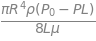

In [18]:
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
P0,PL,rho,mu,R,L,r= sp.symbols('P0,PL,rho,mu,R,L,r')
vz=(P0-PL)*R**2/(4*mu*L)*(1-(r/R)**2)
V=2*sp.pi*sp.integrate(vz*r,(r,0,R))/(2*sp.pi*sp.integrate(r,(r,0,R)))
Q=V*sp.pi*R**2
W=Q*rho
display(sp.simplify(W))

Pour un (P0-PL) donné le débit (en kg/sec) varie en fonction du rayon

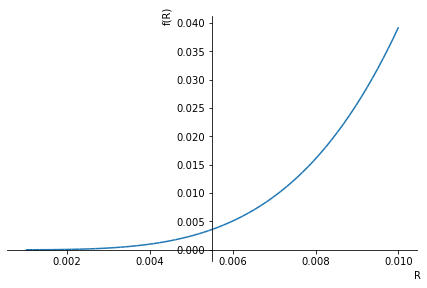

In [19]:
W=W.subs([(rho,1000),(L,100),(mu,0.001),(PL,0),(P0,1000)])
sp.plot(W,(R,0.001,0.01))

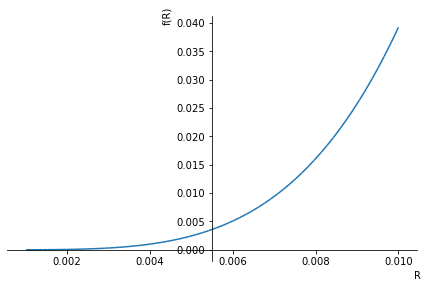

In [20]:
dico={'rho':1000,
       'L'  :1000,
       'mu' :0.001,
       'PL' :0.0,
       'P0' :1000 }
W=W.subs(dico)
sp.plot(W,(R,0.001,0.01))

La force sur la conduite, qui est obtenue en calculant la friction à la paroi multipliée pas la surface. Autrement dit, on multiplie la composante rz du tenseur de Newton par la surface en r=R. Pour une conduite de 6 mm par exemple:

In [21]:
force=sp.diff(vz,r).subs(r,R)*2*sp.pi*R*L
display(force.subs([(rho,1000),(L,100),(mu,0.001),
(PL,0),(P0,1000),(R,0.006)]))

Avec un dictionnaire, on reprend le dictionnaire précédent et on lui ajoute le rayon de la conduite:

In [22]:
force=sp.diff(vz,r).subs(r,R)*2*sp.pi*R*L
dico['R']=0.006;display(force.subs(dico))

In [24]:
r,theta,phi,R=sp.symbols('r,theta,phi,R')
Volume=sp.Integral(r**2*sp.sin(theta),(r,0,R),(theta,0,sp.pi),(phi,0,2*sp.pi))
v1=sp.integrate(r**2*sp.sin(theta),(r,0,R));v2=sp.integrate(v1,(theta,0,sp.pi))
v3=sp.integrate(v2,(phi,0,2*sp.pi));display(v3)# ou 3 intégrales
v3=sp.integrate(r**2*sp.sin(theta),(r,0,R),(theta,0,sp.pi),
                (phi,0,2*sp.pi))